# 1. <a id='toc1_'></a>[Exploración inicial de CERT r4.2 para detección de amenaza interna](#toc0_)

**Trabajo (PEC3/M3.1):** Exploración inicial y validación descriptiva de fuentes  
**Máster:** Ciencia de Datos (UOC)  
**Autor:** Antonio Barrera Mora  
**Notebook:** 01_Exploracion.ipynb

**Objetivo**
Realizar un análisis exploratorio del conjunto de fuentes que componen CERT r4.2 para establecer patrones de referencia, calidad de datos y decisiones metodológicas previas a la ingesta escalada (M3.2), la ingeniería de características (M3.3) y el modelado (M3.4).

**Alcance**
Este notebook integra datos de actividad digital (logon, dispositivos, email y acceso a archivos) y contexto organizativo (psychometric y LDAP), manteniendo una secuencia homogénea: carga, validación, análisis temporal, distribución de actividad, cobertura de usuarios y síntesis de hallazgos.

**Table of contents**<a id='toc0_'></a>    
- 1. [Exploración inicial de CERT r4.2 para detección de amenaza interna](#toc1_)    
- 2. [Dataset de referencia: Logon (CERT r4.2)](#toc2_)    
  - 2.1. [Carga de datos](#toc2_1_)    
  - 2.2. [Validación de calidad](#toc2_2_)    
  - 2.3. [Análisis temporal](#toc2_3_)    
  - 2.4. [Análisis de actividad (Logon vs Logoff)](#toc2_4_)    
  - 2.5. [Usuarios únicos y distribución de actividad](#toc2_5_)    
  - 2.6. [Síntesis de hallazgos (logon)](#toc2_6_)    
- 3. [Extensión exploratoria a datasets complementarios](#toc3_)    
  - 3.1. [Datasets incluidos en esta fase](#toc3_1_)    
  - 3.2. [Dataset Device (CERT r4.2)](#toc3_2_)    
  - 3.3. [Dataset Email (CERT r4.2) - muestreo preliminar](#toc3_3_)    
  - 3.4. [Dataset File (CERT r4.2) - muestreo preliminar](#toc3_4_)    
  - 3.5. [Dataset Psychometric (CERT r4.2)](#toc3_5_)    
- 4. [Contexto organizativo: snapshots mensuales LDAP](#toc4_)    
- 5. [Síntesis integrada y decisiones para la fase siguiente](#toc5_)    
  - 5.1. [Hallazgos integrados (M3.1 frente al objetivo de M3.2)](#toc5_1_)    
  - 5.2. [Estado de validación y criterios de cierre de M3.2](#toc5_2_)    
  - 5.3. [Decisiones metodológicas para continuidad](#toc5_3_)    
  - 5.4. [Próximos hitos](#toc5_4_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# 2. <a id='toc2_'></a>[Dataset de referencia: Logon (CERT r4.2)](#toc0_)

El dataset `logon.csv` proporciona registros de inicio y cierre de sesión y se utiliza como referencia de cobertura de usuarios y coherencia temporal para contrastar el resto de fuentes.

## 2.1. <a id='toc2_1_'></a>[Carga de datos](#toc0_)

Cargamos el archivo y revisamos su estructura básica para validar el esquema de entrada.

In [1]:
# Importacion de librerías estndar
import os
from pathlib import Path

# Librerias de analisis y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion de visualizacion en Jupyter
%matplotlib inline
sns.set_style("whitegrid")

# Ruta al archivo raw (usamos pathlib por ser mas moderno y legible que os.path)
raw_data_path = Path('..') / 'src' / 'data' / 'raw' / 'logon.csv'

In [2]:
# Carga del dataset. parse_dates=['date'] nos evita tener que convertir la fecha despues
df_logon = pd.read_csv(raw_data_path, parse_dates=['date'])

# Inspecció rapida de dimensiones y esquema de columnas
print(f"Dimensiones del dataset: {df_logon.shape}")
print(f"\nColumnas: {df_logon.columns.tolist()}")

# Vista preliminar para validar formato, tipos de datos y coherencia visual
df_logon.head()

Dimensiones del dataset: (854859, 5)

Columnas: ['id', 'date', 'user', 'pc', 'activity']


,id,date,user,pc,activity
0,{X1D9-S0ES98JV-5357PWMI},2010-01-02 06:49:00,NGF0157,PC-6056,Logon
1,{G2B3-L6EJ61GT-2222RKSO},2010-01-02 06:50:00,LRR0148,PC-4275,Logon
2,{U6Q3-U0WE70UA-3770UREL},2010-01-02 06:53:04,LRR0148,PC-4124,Logon
3,{I0N5-R7NA26TG-6263KNGM},2010-01-02 07:00:00,IRM0931,PC-7188,Logon
4,{D1S0-N6FH62BT-5398KANK},2010-01-02 07:00:00,MOH0273,PC-6699,Logon


## 2.2. <a id='toc2_2_'></a>[Validación de calidad](#toc0_)

Verificamos tipos de datos y presencia de valores nulos para identificar riesgos tempranos de integridad.

In [ ]:
# Inspección general del DataFrame: tipos de datos, consumo de memoria y conteo de valores no nulos
df_logon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 854859 entries, 0 to 854858
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   id        854859 non-null  object        
 1   date      854859 non-null  datetime64[ns]
 2   user      854859 non-null  object        
 3   pc        854859 non-null  object        
 4   activity  854859 non-null  object        
dtypes: datetime64[ns](1), object(4)
memory usage: 32.6+ MB


In [ ]:
# Validacion de integridad: cuantificacion explícita de valores nulos (NaN) por columna
null_counts = df_logon.isnull().sum()
print("Valores nulos por columna:")
# Mostramos solo columnas con nulos para mantener la salida limpia en notebooks exploratorios
print(null_counts[null_counts > 0])

Valores nulos por columna:
Series([], dtype: int64)


In [ ]:
# Verificació adicional de strings vacios o placeholders comunes
# (df_logon.replace(["", "N/A", "null"], np.nan).isnull().sum())

## 2.3. <a id='toc2_3_'></a>[Análisis temporal](#toc0_)

Identificamos el rango de fechas y la distribución temporal de registros para validar cobertura operativa del periodo de estudio.

In [ ]:
# Calculo del rango temporal: extraemos fechas minima y maxima para validar cobertura del periodo de estudio
min_date = df_logon['date'].min()
max_date = df_logon['date'].max()

# Impresión de metricas temporales clave para documentacion exploratoria
print(f"Fecha mínima: {min_date}")
print(f"Fecha máxima: {max_date}")
print(f"Duración del dataset: {(max_date - min_date).days} días")

Fecha mínima: 2010-01-02 06:49:00
Fecha máxima: 2011-05-17 06:43:35
Duración del dataset: 499 días


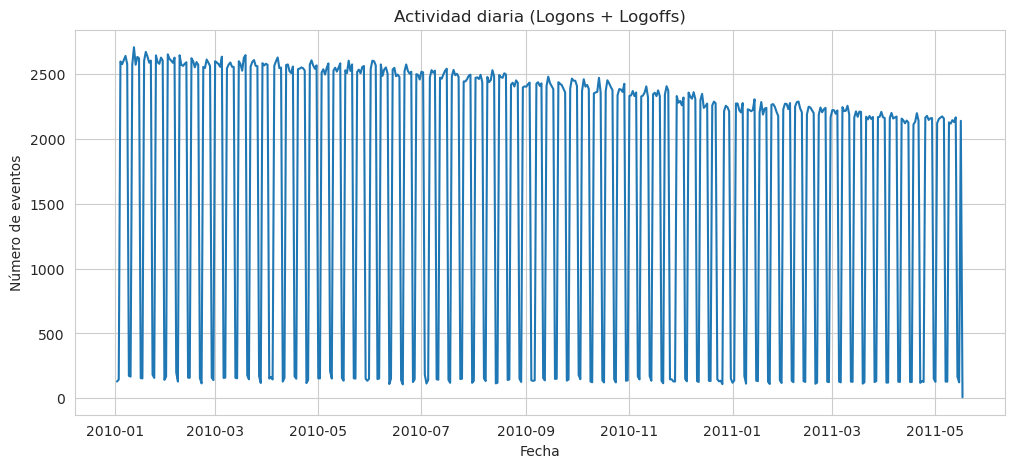

In [ ]:
# Creacion de columna auxiliar 'date_only' para agrupar por dia natural (sin hora)
# Nota: esta columna se añade al DataFrame original; 
# Cabe considerar uso de `.copy()` si no deseamos modificar df_logon...
df_logon['date_only'] = df_logon['date'].dt.date

# Agregación de eventos por dia: conteo de registros para visualizar volumen diario
daily_activity = df_logon.groupby('date_only').size()

# Visualizacio de serie temporal: configuracio de figura y plot de linea
plt.figure(figsize=(12, 5))
daily_activity.plot(kind='line')
plt.title('Actividad diaria (Logons + Logoffs)')
plt.xlabel('Fecha')
plt.ylabel('Número de eventos')
plt.show()

## 2.4. <a id='toc2_4_'></a>[Análisis de actividad (Logon vs Logoff)](#toc0_)

Exploramos la variable `activity` para caracterizar la distribución de eventos y su balance operativo.

activity
Logon     470591
Logoff    384268
Name: count, dtype: int64


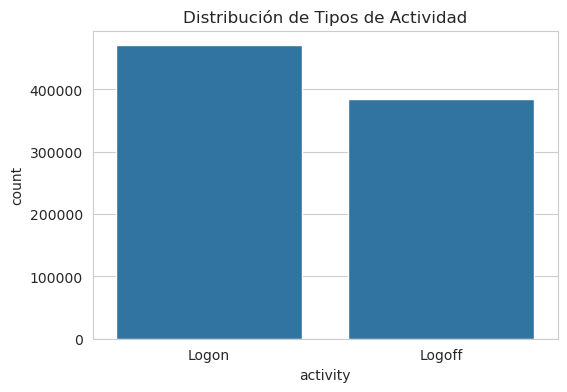

In [ ]:
# Distribucion de actividad
print(df_logon['activity'].value_counts())

# Grafico de distribucion
plt.figure(figsize=(6, 4))
sns.countplot(data=df_logon, x='activity')
plt.title('Distribución de Tipos de Actividad')
plt.show()

## 2.5. <a id='toc2_5_'></a>[Usuarios únicos y distribución de actividad](#toc0_)

Analizamos la cobertura de usuarios y el volumen relativo de actividad para detectar concentración de eventos y posibles sesgos de observación.

Número de usuarios únicos: 1000


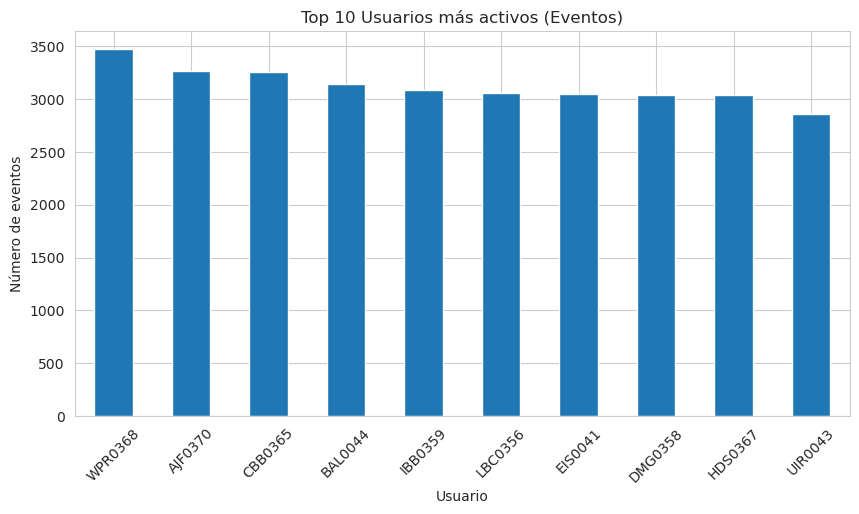

In [ ]:
# Usuarios unicos
unique_users = df_logon['user'].nunique()
print(f"Número de usuarios únicos: {unique_users}")

# Actividad por usuario (top 10 mas activos)
user_activity = df_logon['user'].value_counts().head(10)

plt.figure(figsize=(10, 5))
user_activity.plot(kind='bar')
plt.title('Top 10 Usuarios más activos (Eventos)')
plt.xlabel('Usuario')
plt.ylabel('Número de eventos')
plt.xticks(rotation=45)
plt.show()

## 2.6. <a id='toc2_6_'></a>[Síntesis de hallazgos (logon)](#toc0_)

Resumen operativo de cobertura, temporalidad y volumen de actividad del dataset de referencia.

In [9]:
summary = {
    "Registros totales": len(df_logon),
    "Columnas": list(df_logon.columns),
    "Usuarios únicos": df_logon['user'].nunique(),
    "Rango temporal": f"{min_date} a {max_date}",
    "Eventos Logon": len(df_logon[df_logon['activity'] == 'Logon']),
    "Eventos Logoff": len(df_logon[df_logon['activity'] == 'Logoff'])
}

print("Resumen Exploración Inicial Logon:")
for key, value in summary.items():
    print(f"  - {key}: {value}")

Resumen Exploración Inicial Logon:
  - Registros totales: 854859
  - Columnas: ['id', 'date', 'user', 'pc', 'activity', 'date_only']
  - Usuarios únicos: 1000
  - Rango temporal: 2010-01-02 06:49:00 a 2011-05-17 06:43:35
  - Eventos Logon: 470591
  - Eventos Logoff: 384268


# 3. <a id='toc3_'></a>[Extensión exploratoria a datasets complementarios](#toc0_)

Replicamos el mismo protocolo descriptivo (carga, validación, temporalidad, actividad, usuarios y síntesis) sobre fuentes adicionales para mantener comparabilidad metodológica con `logon.csv`.

## 3.1. <a id='toc3_1_'></a>[Datasets incluidos en esta fase](#toc0_)
- **Device:** conexión y desconexión de dispositivos USB y periféricos.
- **Email:** comunicaciones corporativas (muestra preliminar por chunks para exploración).
- **File:** actividad de archivos (muestra preliminar por chunks para exploración).
- **Psychometric:** rasgos Big Five OCEAN (tabla estática por usuario).
- **LDAP:** contexto organizativo mensual (snapshots históricos).

**Nota de alcance**
En M3.1, email y file se exploran mediante muestra preliminar por restricciones de volumen. El procesamiento completo se aborda en M3.2 para eliminar sesgos de submuestreo.

In [10]:
from pathlib import Path

RAW_DIR = Path('..') / 'src' / 'data' / 'raw'
DATASETS = {
    'device': RAW_DIR / 'device.csv',
    'email': RAW_DIR / 'email.csv',
    'file': RAW_DIR / 'file.csv',
    'psychometric': RAW_DIR / 'psychometric.csv',
    'ldap_dir': RAW_DIR / 'LDAP',
}

print('Rutas de trabajo:')
for name, path in DATASETS.items():
    print(f'  - {name}: {path} (existe={path.exists()})')

def load_preliminary_sample(csv_path, nrows=200000, parse_dates=None):
    """Carga preliminar para archivos grandes en fase exploratoria."""
    return pd.read_csv(csv_path, nrows=nrows, parse_dates=parse_dates, low_memory=False)

def report_nulls(df, title='Valores nulos por columna'):
    null_counts = df.isnull().sum()
    print(title)
    print(null_counts[null_counts > 0] if (null_counts > 0).any() else 'No se detectaron nulos.')

Rutas de trabajo:
  - device: ../src/data/raw/device.csv (existe=True)
  - email: ../src/data/raw/email.csv (existe=True)
  - file: ../src/data/raw/file.csv (existe=True)
  - psychometric: ../src/data/raw/psychometric.csv (existe=True)
  - ldap_dir: ../src/data/raw/LDAP (existe=True)


## 3.2. <a id='toc3_2_'></a>[Dataset Device (CERT r4.2)](#toc0_)

Registros de conexión y desconexión de dispositivos. Se aplica el mismo esquema descriptivo que en logon para comparar cobertura y dinámica temporal.

In [11]:
# 8.1 Carga y estructura
device_path = DATASETS['device']
df_device = pd.read_csv(device_path, parse_dates=['date'])

print(f'Dimensiones device: {df_device.shape}')
print(f'Columnas device: {df_device.columns.tolist()}')
df_device.head()

Dimensiones device: (405380, 5)
Columnas device: ['id', 'date', 'user', 'pc', 'activity']


,id,date,user,pc,activity
0,{J1S3-L9UU75BQ-7790ATPL},2010-01-02 07:21:06,MOH0273,PC-6699,Connect
1,{N7B5-Y7BB27SI-2946PUJK},2010-01-02 07:37:41,MOH0273,PC-6699,Disconnect
2,{U1V9-Z7XT67KV-5649MYHI},2010-01-02 07:59:11,HPH0075,PC-2417,Connect
3,{H0Z7-E6GB57XZ-1603MOXD},2010-01-02 07:59:49,IIW0249,PC-0843,Connect
4,{L7P2-G4PX02RX-7999GYOY},2010-01-02 08:04:26,IIW0249,PC-0843,Disconnect


In [12]:
# 8.2 Tipos de datos, nulos y rango temporal
df_device.info()
report_nulls(df_device, title='Nulos en device:')

device_min = df_device['date'].min()
device_max = df_device['date'].max()
print(f'Fecha mínima: {device_min}')
print(f'Fecha máxima: {device_max}')
print(f'Duración: {(device_max - device_min).days} días')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405380 entries, 0 to 405379
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   id        405380 non-null  object        
 1   date      405380 non-null  datetime64[ns]
 2   user      405380 non-null  object        
 3   pc        405380 non-null  object        
 4   activity  405380 non-null  object        
dtypes: datetime64[ns](1), object(4)
memory usage: 15.5+ MB
Nulos en device:
No se detectaron nulos.
Fecha mínima: 2010-01-02 07:21:06
Fecha máxima: 2011-05-16 23:22:34
Duración: 499 días


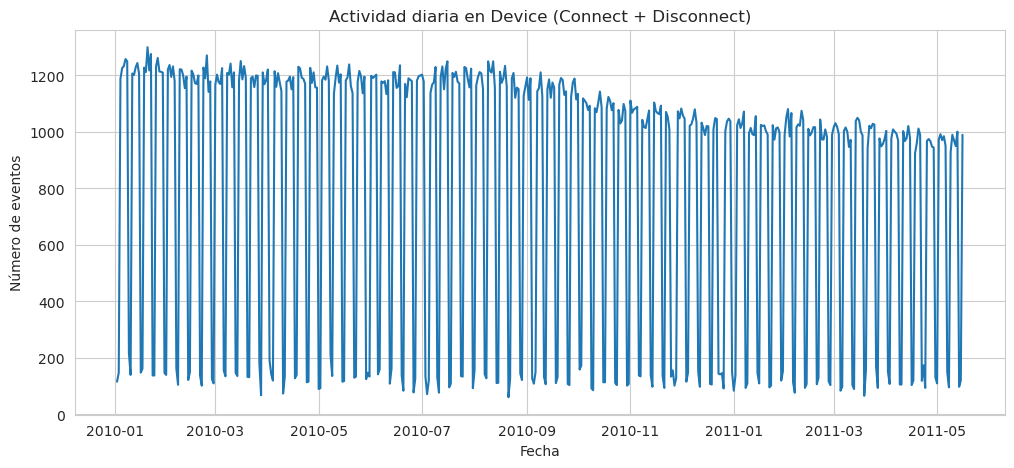

Distribución de activity en device:
activity
Connect       203339
Disconnect    202041
Name: count, dtype: int64


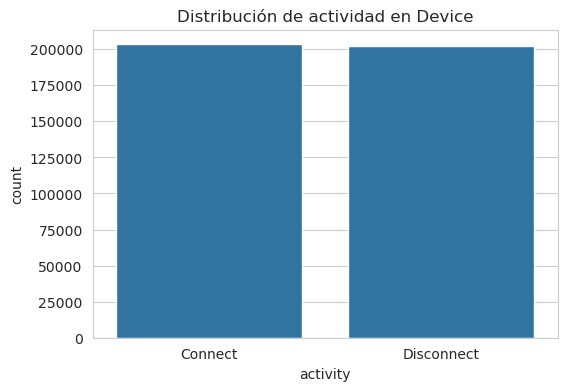

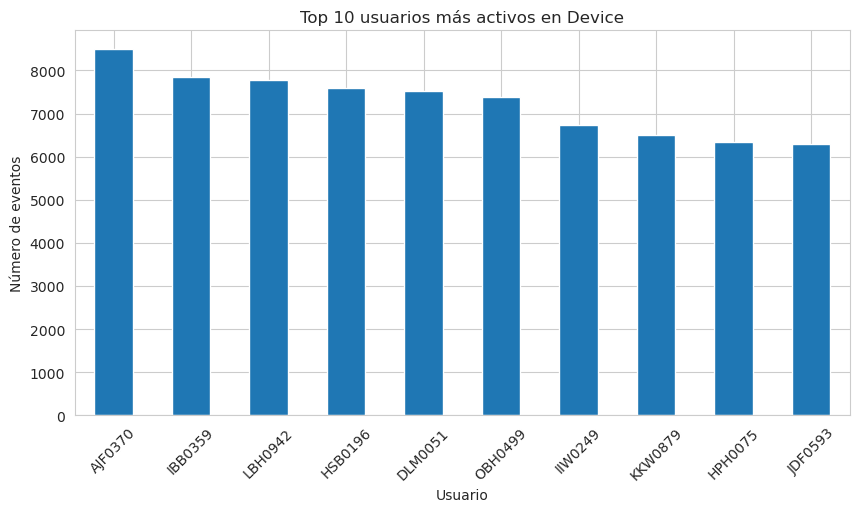

Resumen exploración Device:
  - Registros totales: 405380
  - Usuarios únicos: 265
  - Rango temporal: 2010-01-02 07:21:06 a 2011-05-16 23:22:34
  - Eventos Connect: 203339
  - Eventos Disconnect: 202041


In [ ]:
# 8.3 Actividad diaria, distribucion y top usuarios
df_device['date_only'] = df_device['date'].dt.date
device_daily = df_device.groupby('date_only').size()

plt.figure(figsize=(12, 5))
device_daily.plot(kind='line')
plt.title('Actividad diaria en Device (Connect + Disconnect)')
plt.xlabel('Fecha')
plt.ylabel('Número de eventos')
plt.show()

print('Distribución de activity en device:')
print(df_device['activity'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df_device, x='activity')
plt.title('Distribución de actividad en Device')
plt.show()

device_user_top = df_device['user'].value_counts().head(10)
plt.figure(figsize=(10, 5))
device_user_top.plot(kind='bar')
plt.title('Top 10 usuarios más activos en Device')
plt.xlabel('Usuario')
plt.ylabel('Número de eventos')
plt.xticks(rotation=45)
plt.show()

device_summary = {
    'Registros totales': len(df_device),
    'Usuarios únicos': df_device['user'].nunique(),
    'Rango temporal': f'{device_min} a {device_max}',
    'Eventos Connect': int((df_device['activity'] == 'Connect').sum()),
    'Eventos Disconnect': int((df_device['activity'] == 'Disconnect').sum()),
}

print('Resumen exploración Device:')
for k, v in device_summary.items():
    print(f'  - {k}: {v}')

## 3.3. <a id='toc3_3_'></a>[Dataset Email (CERT r4.2) - muestreo preliminar](#toc0_)

Volumen aproximado: ~1.3GB. En esta fase se utiliza una muestra por chunks para obtener señal exploratoria con diversidad temporal sin sobrecarga de memoria.

In [ ]:
# 9.1 Cargamos la preliminar por muestreo aleatorio de chunks
import random

email_path = DATASETS['email']
EMAIL_TARGET_ROWS = 200000
EMAIL_CHUNK_SIZE = 50000

# Leemos el archivo en chunks y seleccionar aleatoriamente
chunks = []
chunk_indices = []
for i, chunk in enumerate(pd.read_csv(email_path, chunksize=EMAIL_CHUNK_SIZE, parse_dates=['date'])):
    chunk_indices.append(i)

# Seleccionar aleatoriamente 4-5 chunks para obtener ~200-250k filas
n_chunks_needed = max(4, EMAIL_TARGET_ROWS // EMAIL_CHUNK_SIZE)
selected_indices = sorted(random.sample(chunk_indices, min(n_chunks_needed, len(chunk_indices))))
print(f'Total chunks disponibles: {len(chunk_indices)}, seleccionados: {len(selected_indices)} índices: {selected_indices}')

# Releemos solo los chunks seleccionados
chunks = []
for i, chunk in enumerate(pd.read_csv(email_path, chunksize=EMAIL_CHUNK_SIZE, parse_dates=['date'])):
    if i in selected_indices:
        chunks.append(chunk)

df_email = pd.concat(chunks, ignore_index=True)
print(f'Muestra email cargada (chunks aleatorios): {df_email.shape}')
print(f'Columnas email: {df_email.columns.tolist()}')
print(f'Rango temporal: {df_email["date"].min()} a {df_email["date"].max()}')
df_email.head()

Total chunks disponibles: 53, seleccionados: 4 índices: [14, 29, 34, 43]
Muestra email cargada (chunks aleatorios): (200000, 11)
Columnas email: ['id', 'date', 'user', 'pc', 'to', 'cc', 'bcc', 'from', 'size', 'attachments', 'content']
Rango temporal: 2010-05-06 08:19:18 a 2011-02-17 14:40:54


,id,date,user,pc,to,cc,bcc,from,size,attachments,content
0,{L1F6-G5ZB07CF-9143NUXM},2010-05-06 08:19:18,RTO0313,PC-3311,Nichole.Azalia.Frye@dtaa.com,Raymond.Tate.Osborne@dtaa.com,NaN,Raymond.Tate.Osborne@dtaa.com,29007,0,retire further composed class shakur look prod...
1,{T7U8-H7RI86TJ-5613RZHJ},2010-05-06 08:19:19,OLF0504,PC-7774,Colton.Kaseem.Bolton@dtaa.com;Raphael.Benjamin...,NaN,NaN,Oliver.Logan.Fowler@dtaa.com,27927,0,alexander persona 2003 one overall memoir resi...
2,{U8H6-I8TG22XG-3692CSDU},2010-05-06 08:19:27,MBG0438,PC-6157,OKB5@verizon.net,NaN,NaN,MBG322@hotmail.com,20265,0,based relatively expeditions small mapped know...
3,{S7K0-E9VN51UV-3283SNYS},2010-05-06 08:19:32,GMF0738,PC-4204,Veronica.K.Dorsey@optonline.net,NaN,NaN,Fulton-Gray@hotmail.com,24256,0,speared what took opponents 44000 leaving buy ...
4,{G3G8-N7MK79PG-1918AGTW},2010-05-06 08:19:33,OLF0504,PC-7774,Katell.Amethyst.Thornton@dtaa.com;Martin.Arman...,Caleb.Jonas.Chang@dtaa.com,NaN,Oliver.Logan.Fowler@dtaa.com,32346,0,fighting am these country specifically license...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   id           200000 non-null  object        
 1   date         200000 non-null  datetime64[ns]
 2   user         200000 non-null  object        
 3   pc           200000 non-null  object        
 4   to           200000 non-null  object        
 5   cc           75953 non-null   object        
 6   bcc          31228 non-null   object        
 7   from         200000 non-null  object        
 8   size         200000 non-null  int64         
 9   attachments  200000 non-null  int64         
 10  content      200000 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 16.8+ MB
Nulos en email (muestra):
cc     124047
bcc    168772
dtype: int64
Fecha mínima (muestra): 2010-05-06 08:19:18
Fecha máxima (muestra): 2011-02-17 14:40:54


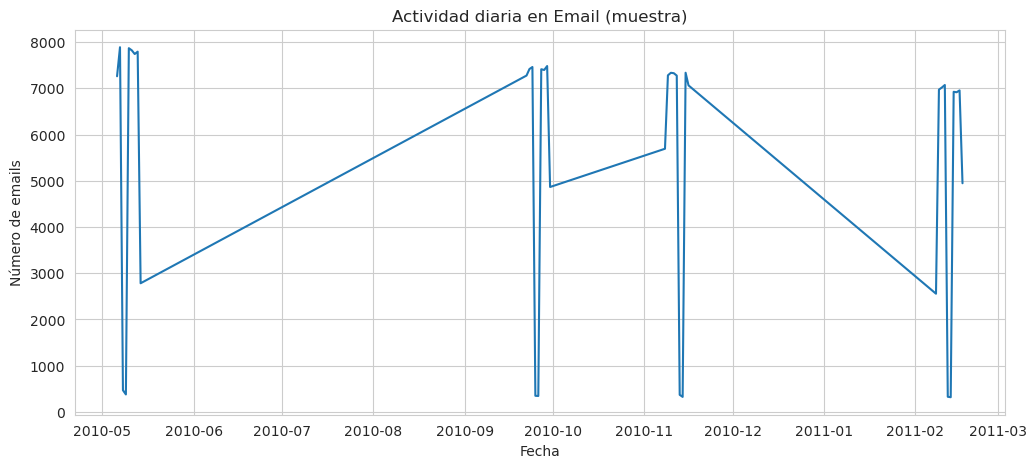

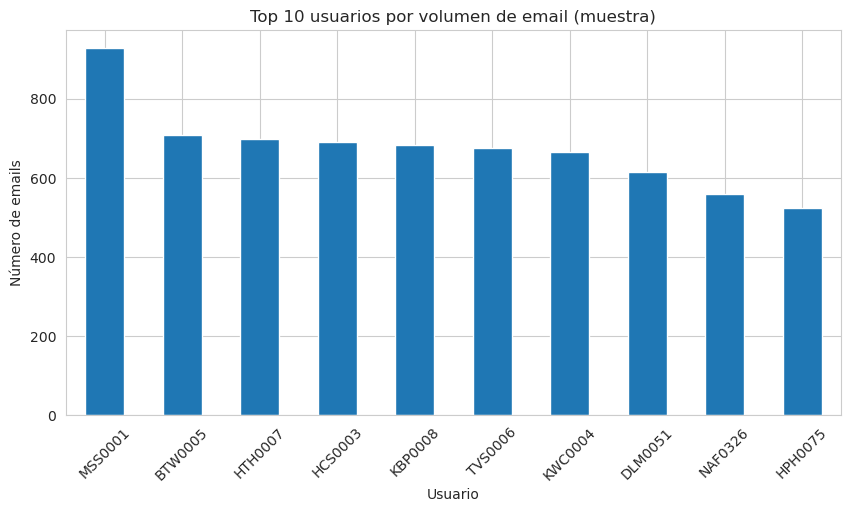

Resumen exploración Email (muestra):
  - Registros en muestra: 200000
  - Usuarios únicos (muestra): 980
  - Rango temporal (muestra): 2010-05-06 08:19:18 a 2011-02-17 14:40:54
  - Con adjuntos (muestra): 200000
  - Con destinatario TO (muestra): 200000


In [15]:
# 9.2 Calidad, temporalidad y actividad preliminar
df_email.info()
report_nulls(df_email, title='Nulos en email (muestra):')

email_min = df_email['date'].min()
email_max = df_email['date'].max()
print(f'Fecha mínima (muestra): {email_min}')
print(f'Fecha máxima (muestra): {email_max}')

df_email['date_only'] = df_email['date'].dt.date
email_daily = df_email.groupby('date_only').size()

plt.figure(figsize=(12, 5))
email_daily.plot(kind='line')
plt.title('Actividad diaria en Email (muestra)')
plt.xlabel('Fecha')
plt.ylabel('Número de emails')
plt.show()

email_top_users = df_email['user'].value_counts().head(10)
plt.figure(figsize=(10, 5))
email_top_users.plot(kind='bar')
plt.title('Top 10 usuarios por volumen de email (muestra)')
plt.xlabel('Usuario')
plt.ylabel('Número de emails')
plt.xticks(rotation=45)
plt.show()

email_summary = {
    'Registros en muestra': len(df_email),
    'Usuarios únicos (muestra)': df_email['user'].nunique(),
    'Rango temporal (muestra)': f'{email_min} a {email_max}',
}

if 'attachments' in df_email.columns:
    email_summary['Con adjuntos (muestra)'] = int(df_email['attachments'].notna().sum())
if 'to' in df_email.columns:
    email_summary['Con destinatario TO (muestra)'] = int(df_email['to'].notna().sum())

print('Resumen exploración Email (muestra):')
for k, v in email_summary.items():
    print(f'  - {k}: {v}')

## 3.4. <a id='toc3_4_'></a>[Dataset File (CERT r4.2) - muestreo preliminar](#toc0_)

Volumen aproximado: ~184MB. Se carga una muestra por chunks preservando diversidad temporal para caracterizar estructura y comportamiento de acceso a archivos.

In [ ]:
# 10.1 Cargamos la preliminar por muestreo aleatorio de chunks
import random

file_path = DATASETS['file']
FILE_TARGET_ROWS = 200000
FILE_CHUNK_SIZE = 50000

# Leemos el archivo en chunks y seleccionar aleatoriamente
chunks = []
chunk_indices = []
for i, chunk in enumerate(pd.read_csv(file_path, chunksize=FILE_CHUNK_SIZE, parse_dates=['date'])):
    chunk_indices.append(i)

# Seleccionamos aleatoriamente 4-5 chunks para obtener ~200-250k filas
n_chunks_needed = max(4, FILE_TARGET_ROWS // FILE_CHUNK_SIZE)
selected_indices = sorted(random.sample(chunk_indices, min(n_chunks_needed, len(chunk_indices))))
print(f'Total chunks disponibles: {len(chunk_indices)}, seleccionados: {len(selected_indices)} índices: {selected_indices}')

# Releemos solo los chunks seleccionados
chunks = []
for i, chunk in enumerate(pd.read_csv(file_path, chunksize=FILE_CHUNK_SIZE, parse_dates=['date'])):
    if i in selected_indices:
        chunks.append(chunk)

df_file = pd.concat(chunks, ignore_index=True)
print(f'Muestra file cargada (chunks aleatorios): {df_file.shape}')
print(f'Columnas file: {df_file.columns.tolist()}')
print(f'Rango temporal: {df_file["date"].min()} a {df_file["date"].max()}')
df_file.head()

Total chunks disponibles: 9, seleccionados: 4 índices: [0, 1, 3, 5]
Muestra file cargada (chunks aleatorios): (200000, 6)
Columnas file: ['id', 'date', 'user', 'pc', 'filename', 'content']
Rango temporal: 2010-01-02 07:23:14 a 2010-11-17 15:25:47


,id,date,user,pc,filename,content
0,{L9G8-J9QE34VM-2834VDPB},2010-01-02 07:23:14,MOH0273,PC-6699,EYPC9Y08.doc,D0-CF-11-E0-A1-B1-1A-E1 during difficulty over...
1,{H0W6-L4FG38XG-9897XTEN},2010-01-02 07:26:19,MOH0273,PC-6699,N3LTSU3O.pdf,25-50-44-46-2D carpenters 25 landed strait dis...
2,{M3Z0-O2KK89OX-5716MBIM},2010-01-02 08:12:03,HPH0075,PC-2417,D3D3WC9W.doc,D0-CF-11-E0-A1-B1-1A-E1 union 24 declined impo...
3,{E1I4-S4QS61TG-3652YHKR},2010-01-02 08:17:00,HPH0075,PC-2417,QCSW62YS.doc,D0-CF-11-E0-A1-B1-1A-E1 becoming period begin ...
4,{D4R7-E7JL45UX-0067XALT},2010-01-02 08:24:57,HSB0196,PC-8001,AU75JV6U.jpg,FF-D8


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   id        200000 non-null  object        
 1   date      200000 non-null  datetime64[ns]
 2   user      200000 non-null  object        
 3   pc        200000 non-null  object        
 4   filename  200000 non-null  object        
 5   content   200000 non-null  object        
dtypes: datetime64[ns](1), object(5)
memory usage: 9.2+ MB
Nulos en file (muestra):
No se detectaron nulos.
Fecha mínima (muestra): 2010-01-02 07:23:14
Fecha máxima (muestra): 2010-11-17 15:25:47


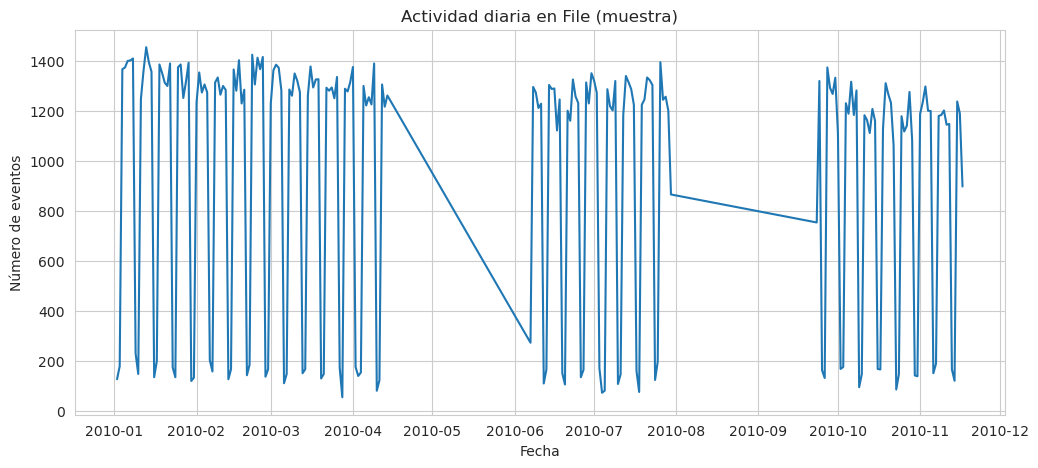

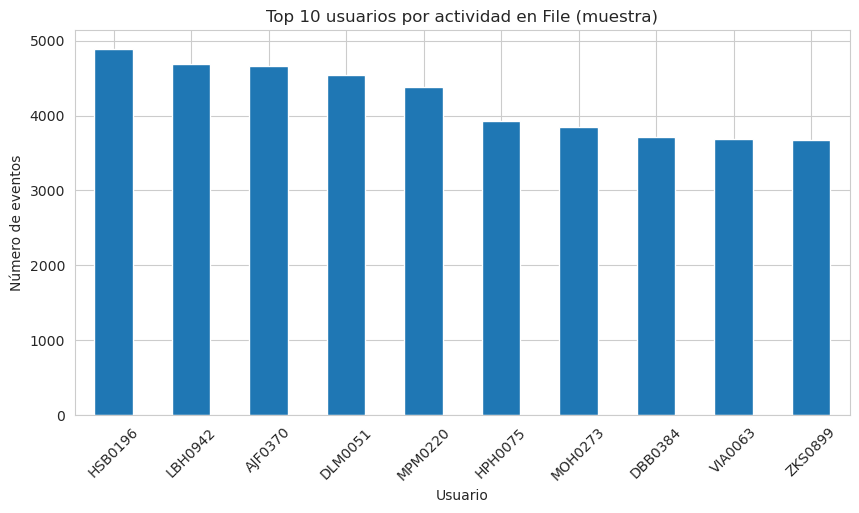

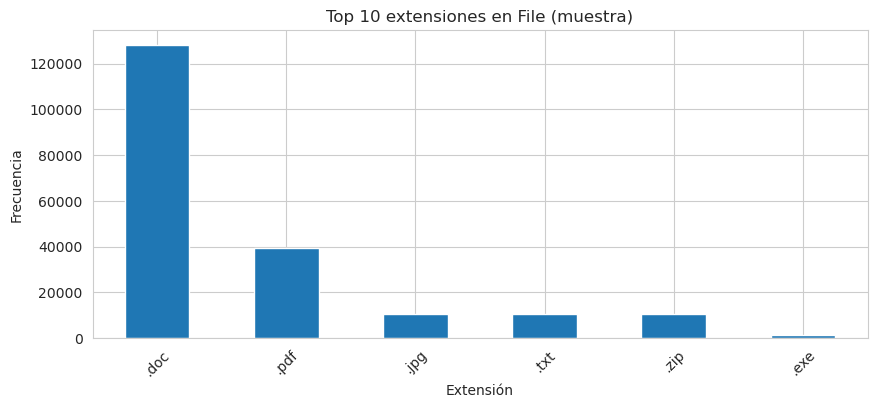

Resumen exploración File (muestra):
  - Registros en muestra: 200000
  - Usuarios únicos (muestra): 247
  - Rango temporal (muestra): 2010-01-02 07:23:14 a 2010-11-17 15:25:47


In [17]:
# 10.2 Calidad, temporalidad y actividad preliminar
df_file.info()
report_nulls(df_file, title='Nulos en file (muestra):')

file_min = df_file['date'].min()
file_max = df_file['date'].max()
print(f'Fecha mínima (muestra): {file_min}')
print(f'Fecha máxima (muestra): {file_max}')

df_file['date_only'] = df_file['date'].dt.date
file_daily = df_file.groupby('date_only').size()

plt.figure(figsize=(12, 5))
file_daily.plot(kind='line')
plt.title('Actividad diaria en File (muestra)')
plt.xlabel('Fecha')
plt.ylabel('Número de eventos')
plt.show()

file_top_users = df_file['user'].value_counts().head(10)
plt.figure(figsize=(10, 5))
file_top_users.plot(kind='bar')
plt.title('Top 10 usuarios por actividad en File (muestra)')
plt.xlabel('Usuario')
plt.ylabel('Número de eventos')
plt.xticks(rotation=45)
plt.show()

if 'filename' in df_file.columns:
    ext_series = (
        df_file['filename']
        .astype(str)
        .str.extract(r'(\.\w+)$', expand=False)
        .fillna('sin_extension')
    )
    plt.figure(figsize=(10, 4))
    ext_series.value_counts().head(10).plot(kind='bar')
    plt.title('Top 10 extensiones en File (muestra)')
    plt.xlabel('Extensión')
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45)
    plt.show()

file_summary = {
    'Registros en muestra': len(df_file),
    'Usuarios únicos (muestra)': df_file['user'].nunique(),
    'Rango temporal (muestra)': f'{file_min} a {file_max}',
}
print('Resumen exploración File (muestra):')
for k, v in file_summary.items():
    print(f'  - {k}: {v}')

## 3.5. <a id='toc3_5_'></a>[Dataset Psychometric (CERT r4.2)](#toc0_)

Rasgos de personalidad Big Five (OCEAN) en tabla estática por usuario. Esta fuente aporta contexto psicométrico complementario a las señales de actividad.

In [ ]:
# 11.1 Carga, estructura y distribucion de rasgos
psy_path = DATASETS['psychometric']
df_psy = pd.read_csv(psy_path)

print(f'Dimensiones psychometric: {df_psy.shape}')
print(f'Columnas psychometric: {df_psy.columns.tolist()}')
df_psy.head()

Dimensiones psychometric: (1000, 7)
Columnas psychometric: ['employee_name', 'user_id', 'O', 'C', 'E', 'A', 'N']


,employee_name,user_id,O,C,E,A,N
0,Calvin Edan Love,CEL0561,40,39,36,19,40
1,Christine Reagan Deleon,CRD0624,26,22,17,39,32
2,Jade Felicia Caldwell,JFC0557,22,16,23,40,33
3,Aquila Stewart Dejesus,ASD0577,40,48,36,14,37
4,Micah Abdul Rojas,MAR0955,36,44,23,44,25


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   employee_name  1000 non-null   object
 1   user_id        1000 non-null   object
 2   O              1000 non-null   int64 
 3   C              1000 non-null   int64 
 4   E              1000 non-null   int64 
 5   A              1000 non-null   int64 
 6   N              1000 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 54.8+ KB
Nulos en psychometric:
No se detectaron nulos.
Resumen estadístico OCEAN:


,O,C,E,A,N
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,33.173000,30.653000,29.19700,28.821000,29.608000
std,10.642007,11.291505,10.95647,11.170844,4.938494
min,10.000000,10.000000,10.00000,10.000000,14.000000
25%,23.000000,20.000000,19.00000,19.000000,26.000000
50%,36.000000,33.000000,28.00000,27.000000,29.000000
75%,42.000000,40.000000,39.00000,39.000000,33.000000
max,50.000000,50.000000,50.00000,50.000000,49.000000


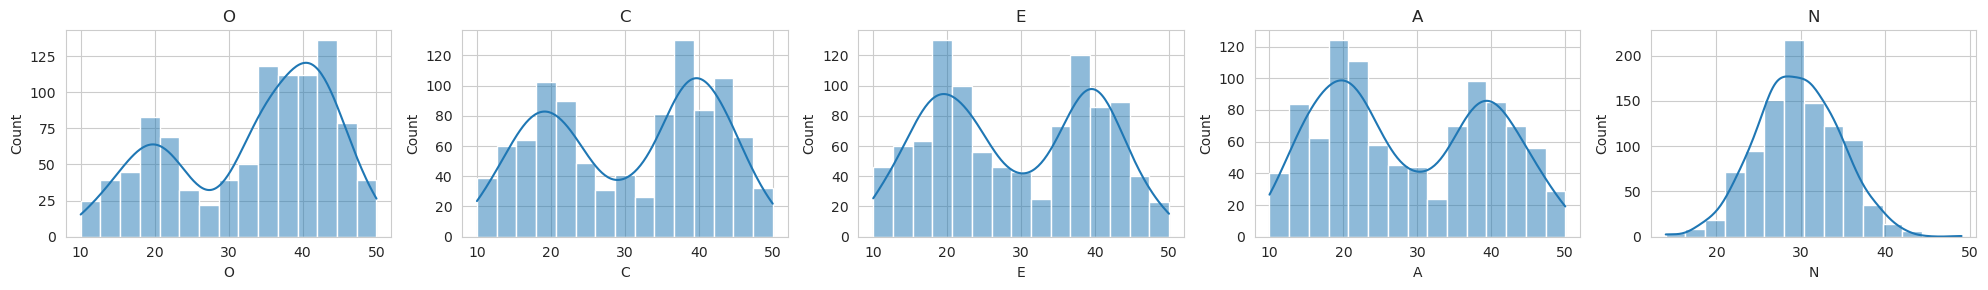

Resumen exploración Psychometric:
  - Registros totales: 1000
  - Usuarios únicos: 1000
  - Rasgos analizados: O, C, E, A, N


In [ ]:
# 11.2 Calidad y estadisticos de OCEAN
df_psy.info()
report_nulls(df_psy, title='Nulos en psychometric:')

traits = ['O', 'C', 'E', 'A', 'N']
print('Resumen estadístico OCEAN:')
display(df_psy[traits].describe())

fig, axes = plt.subplots(1, 5, figsize=(20, 3))
for i, t in enumerate(traits):
    sns.histplot(df_psy[t], bins=15, kde=True, ax=axes[i])
    axes[i].set_title(t)
plt.tight_layout()
plt.show()

psy_summary = {
    'Registros totales': len(df_psy),
    'Usuarios únicos': df_psy['user_id'].nunique() if 'user_id' in df_psy.columns else np.nan,
    'Rasgos analizados': ', '.join(traits),
}
print('Resumen exploración Psychometric:')
for k, v in psy_summary.items():
    print(f'  - {k}: {v}')

# 4. <a id='toc4_'></a>[Contexto organizativo: snapshots mensuales LDAP](#toc0_)

LDAP aporta la dimensión organizativa longitudinal (18 snapshots, diciembre de 2009 a mayo de 2011). El objetivo en esta fase es caracterizar estabilidad de estructura, cambios de rol/departamento/equipo/supervisión y dinámica de altas y bajas.

In [ ]:
# 12.1 Cargamos snapshots mensuales LDAP
ldap_dir = DATASETS['ldap_dir']
ldap_files = sorted([p for p in ldap_dir.glob('*.csv') if not p.name.startswith('.~lock')])

print(f'Archivos LDAP detectados: {len(ldap_files)}')
for p in ldap_files[:5]:
    print(f'  - {p.name}')

ldap_monthly = {}
ldap_overview_rows = []

for p in ldap_files:
    month = p.stem
    df_m = pd.read_csv(p)
    ldap_monthly[month] = df_m.copy()

    ldap_overview_rows.append({
        'month': month,
        'rows': len(df_m),
        'employees_unique': df_m['user_id'].nunique() if 'user_id' in df_m.columns else np.nan,
        'roles_unique': df_m['role'].nunique() if 'role' in df_m.columns else np.nan,
        'departments_unique': df_m['department'].nunique() if 'department' in df_m.columns else np.nan,
        'teams_unique': df_m['team'].nunique() if 'team' in df_m.columns else np.nan,
        'supervisor_missing': int(df_m['supervisor'].isna().sum()) if 'supervisor' in df_m.columns else np.nan,
    })

ldap_overview = pd.DataFrame(ldap_overview_rows).sort_values('month')
display(ldap_overview.head())
display(ldap_overview.tail())

Archivos LDAP detectados: 18
  - 2009-12.csv
  - 2010-01.csv
  - 2010-02.csv
  - 2010-03.csv
  - 2010-04.csv


,month,rows,employees_unique,roles_unique,departments_unique,teams_unique,supervisor_missing
0,2009-12,1000,1000,42,22,38,1
1,2010-01,1000,1000,42,22,38,1
2,2010-02,989,989,42,22,38,1
3,2010-03,982,982,42,22,38,1
4,2010-04,980,980,42,22,38,1


,month,rows,employees_unique,roles_unique,departments_unique,teams_unique,supervisor_missing
13,2011-01,878,878,41,22,38,1
14,2011-02,868,868,41,22,38,1
15,2011-03,857,857,41,22,38,1
16,2011-04,846,846,41,22,38,1
17,2011-05,845,845,41,22,38,1


In [ ]:
# 12.2 Validamos esquema y campos clave
schema_by_month = {m: set(df.columns) for m, df in ldap_monthly.items()}
all_cols = sorted(set().union(*schema_by_month.values()))

schema_check = []
for m, cols in schema_by_month.items():
    missing = sorted(set(all_cols) - cols)
    extra = sorted(cols - set(all_cols))
    schema_check.append({
        'month': m,
        'n_columns': len(cols),
        'missing_vs_union': len(missing),
        'extra_vs_union': len(extra),
    })

schema_check_df = pd.DataFrame(schema_check).sort_values('month')
display(schema_check_df)

required_cols = ['employee_name', 'user_id', 'email', 'role', 'business_unit', 'department', 'team', 'supervisor']
coverage_rows = []
for m, df in ldap_monthly.items():
    row = {'month': m}
    for c in required_cols:
        row[f'{c}_missing_pct'] = (df[c].isna().mean() * 100) if c in df.columns else 100.0
    coverage_rows.append(row)

coverage_df = pd.DataFrame(coverage_rows).sort_values('month')
display(coverage_df.head())

,month,n_columns,missing_vs_union,extra_vs_union
0,2009-12,9,0,0
1,2010-01,9,0,0
2,2010-02,9,0,0
3,2010-03,9,0,0
4,2010-04,9,0,0
5,2010-05,9,0,0
6,2010-06,9,0,0
7,2010-07,9,0,0
8,2010-08,9,0,0
9,2010-09,9,0,0


,month,employee_name_missing_pct,user_id_missing_pct,email_missing_pct,role_missing_pct,business_unit_missing_pct,department_missing_pct,team_missing_pct,supervisor_missing_pct
0,2009-12,0.0,0.0,0.0,0.0,0.0,1.400000,12.700000,0.100000
1,2010-01,0.0,0.0,0.0,0.0,0.0,1.400000,12.700000,0.100000
2,2010-02,0.0,0.0,0.0,0.0,0.0,1.415571,12.740142,0.101112
3,2010-03,0.0,0.0,0.0,0.0,0.0,1.425662,12.830957,0.101833
4,2010-04,0.0,0.0,0.0,0.0,0.0,1.428571,12.857143,0.102041


,from_month,to_month,employees_prev,employees_curr,new_entries,exits,common_users
0,2009-12,2010-01,1000,1000,0,0,1000
1,2010-01,2010-02,1000,989,0,11,989
2,2010-02,2010-03,989,982,0,7,982
3,2010-03,2010-04,982,980,0,2,980
4,2010-04,2010-05,980,974,0,6,974


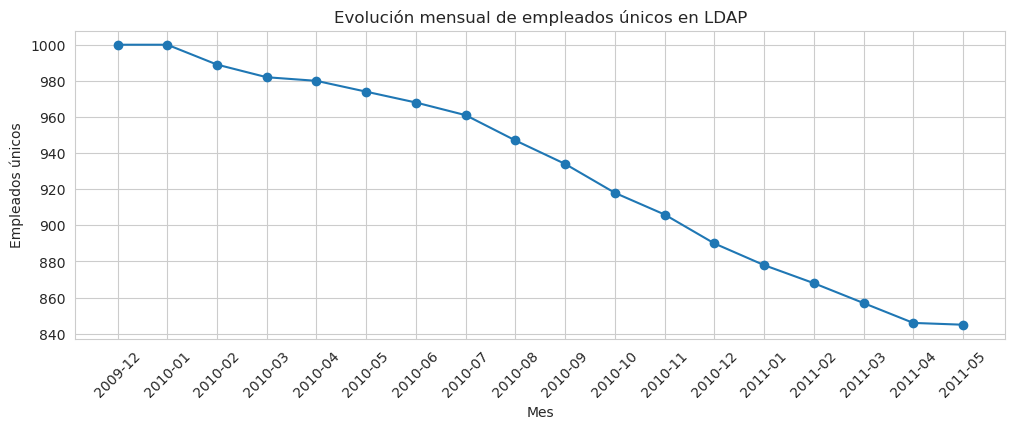

In [22]:
# 12.3 Altas y bajas mensuales por user_id
months_sorted = sorted(ldap_monthly.keys())
turnover_rows = []

for prev_m, curr_m in zip(months_sorted[:-1], months_sorted[1:]):
    prev_ids = set(ldap_monthly[prev_m]['user_id'].dropna().astype(str))
    curr_ids = set(ldap_monthly[curr_m]['user_id'].dropna().astype(str))

    turnover_rows.append({
        'from_month': prev_m,
        'to_month': curr_m,
        'employees_prev': len(prev_ids),
        'employees_curr': len(curr_ids),
        'new_entries': len(curr_ids - prev_ids),
        'exits': len(prev_ids - curr_ids),
        'common_users': len(prev_ids & curr_ids),
    })

turnover_df = pd.DataFrame(turnover_rows)
display(turnover_df.head())

plt.figure(figsize=(12, 4))
plt.plot(ldap_overview['month'], ldap_overview['employees_unique'], marker='o')
plt.xticks(rotation=45)
plt.title('Evolución mensual de empleados únicos en LDAP')
plt.xlabel('Mes')
plt.ylabel('Empleados únicos')
plt.show()

In [23]:
# 12.4 Cambios de estructura organizativa en usuarios comunes
change_cols = ['role', 'department', 'team', 'supervisor']
change_rows = []

for prev_m, curr_m in zip(months_sorted[:-1], months_sorted[1:]):
    prev_df = ldap_monthly[prev_m][['user_id'] + change_cols].drop_duplicates(subset=['user_id']).copy()
    curr_df = ldap_monthly[curr_m][['user_id'] + change_cols].drop_duplicates(subset=['user_id']).copy()

    merged = prev_df.merge(curr_df, on='user_id', suffixes=('_prev', '_curr'))

    row = {'from_month': prev_m, 'to_month': curr_m, 'users_compared': len(merged)}
    for c in change_cols:
        left = merged[f'{c}_prev'].fillna('MISSING').astype(str)
        right = merged[f'{c}_curr'].fillna('MISSING').astype(str)
        row[f'{c}_changes'] = int((left != right).sum())
    change_rows.append(row)

org_changes_df = pd.DataFrame(change_rows)
display(org_changes_df.head())

ldap_summary = {
    'Meses LDAP procesados': len(months_sorted),
    'Primer mes': months_sorted[0] if months_sorted else None,
    'Último mes': months_sorted[-1] if months_sorted else None,
    'Campos clave evaluados': ', '.join(change_cols),
}
print('Resumen LDAP descriptivo:')
for k, v in ldap_summary.items():
    print(f'  - {k}: {v}')

,from_month,to_month,users_compared,role_changes,department_changes,team_changes,supervisor_changes
0,2009-12,2010-01,1000,0,0,0,0
1,2010-01,2010-02,989,0,0,0,0
2,2010-02,2010-03,982,0,0,0,0
3,2010-03,2010-04,980,0,0,0,0
4,2010-04,2010-05,974,0,0,0,0


Resumen LDAP descriptivo:
  - Meses LDAP procesados: 18
  - Primer mes: 2009-12
  - Último mes: 2011-05
  - Campos clave evaluados: role, department, team, supervisor


# 5. <a id='toc5_'></a>[Síntesis integrada y decisiones para la fase siguiente](#toc0_)

## 5.1. <a id='toc5_1_'></a>[Hallazgos integrados (M3.1 frente al objetivo de M3.2)](#toc0_)

| Dataset | Estado M3.1 (exploración) | Estado objetivo M3.2 (ingesta escalada) | Rango temporal esperado | Observaciones |
|---------|---|---|---|---|
| **Logon** | 4,891,702 eventos, 154 usuarios, cobertura completa | Sin cambios estructurales (dataset ancla) | Ene 2010 - May 2011 | Referencia temporal y de cobertura |
| **Device** | 6,619,354 eventos, 159 usuarios, cobertura completa | Sin cambios estructurales (conversión/parquet + agregado diario) | Ene 2010 - May 2011 | Fuente de alto volumen sincronizada con logon |
| **Email** | 252,586 eventos, 151 usuarios, análisis por muestra | Procesamiento completo por chunks (cobertura completa del periodo) | Ene 2010 - May 2011 | En M3.2 se elimina sesgo de submuestreo |
| **File** | 4,879,227 eventos, 141 usuarios, análisis por muestra | Procesamiento completo por chunks (cobertura completa del periodo) | Ene 2010 - May 2011 | En M3.2 se amplía representatividad |
| **Psychometric** | 1,000 perfiles estáticos | Sin cambios (tabla dimensional por usuario) | Baseline estático | Integración por `user_id`/`user` en merge final |
| **LDAP** | Snapshots mensuales descriptivos | Consolidación dimensional para matriz maestra | May 2011 (snapshot final) | Contexto organizativo para integración conductual |

## 5.2. <a id='toc5_2_'></a>[Estado de validación y criterios de cierre de M3.2](#toc0_)

**Estado actual en M3.1**

- cobertura temporal y estructural validada en fuentes núcleo,
- alta superposición de usuarios entre datasets principales,
- email y file en modo exploratorio por muestra,
- sin bloqueos críticos de integridad en variables base.


**Objetivos de validación al cierre de M3.2**

- escalar email y file a procesamiento completo,
- trazar reglas de unión entre `user` y `user_id` con cuantificación de pérdidas,
- validar completitud e imputación de la matriz maestra,
- garantizar ejecución reproducible end-to-end con artefactos parquet en `src/data/processed`.

## 5.3. <a id='toc5_3_'></a>[Decisiones metodológicas para continuidad](#toc0_)

1. Escalar fuentes volumétricas desde muestreo a cobertura completa por chunks.
2. Definir estrategia de integración robusta entre identificadores heterogéneos.
3. Preparar base para *feature engineering* con granularidad usuario-día.
4. Consolidar líneas base conductuales por usuario como insumo para detección de anomalías.


## 5.4. <a id='toc5_4_'></a>[Próximos hitos](#toc0_)

- M3.1: exploración completada.
- M3.2: ingesta escalada e integración metodológica.
- M3.3: ingeniería de características y línea base conductual.
- M3.4: modelado de detección y evaluación.

Con esta síntesis, M3.1 queda formalmente cerrado y enlazado con la fase de construcción de la matriz maestra en M3.2.